In [ ]:
#!pip install -U llama-cpp-python
!pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu122

Looking in indexes: https://pypi.org/simple, https://abetlen.github.io/llama-cpp-python/whl/cu122


## Local Inference on GPU
Model page: https://huggingface.co/ijohn07/Holo-3.1-4B-Q6_K-GGUF

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/ijohn07/Holo-3.1-4B-Q6_K-GGUF)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
# !pip install llama-cpp-python

from llama_cpp import Llama

llm = Llama.from_pretrained(
	repo_id="ijohn07/Holo-3.1-4B-Q6_K-GGUF",
	filename="holo-3.1-4b-q6_k.gguf",
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


./holo-3.1-4b-q6_k.gguf:   0%|          | 0.00/3.99G [00:00<?, ?B/s]

llama_model_loader: loaded meta data with 53 key-value pairs and 427 tensors from /root/.cache/huggingface/hub/models--ijohn07--Holo-3.1-4B-Q6_K-GGUF/snapshots/5c10f1edd51574c68451098fb923f60a7626edbf/./holo-3.1-4b-q6_k.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen35
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                     general.sampling.top_k i32              = 20
llama_model_loader: - kv   3:                     general.sampling.top_p f32              = 0.950000
llama_model_loader: - kv   4:                      general.sampling.temp f32              = 1.000000
llama_model_loader: - kv   5:                               general.name str              = Holo 3.1 4B
llama_model_loader: - kv   6:                       

In [ ]:
llm.create_chat_completion(
	messages = [
		{
			"role": "user",
			"content": [
				{
					"type": "text",
					"text": "Describe this image in one sentence."
				},
				{
					"type": "image_url",
					"image_url": {
						"url": "https://cdn.britannica.com/61/93061-050-99147DCE/Statue-of-Liberty-Island-New-York-Bay.jpg"
					}
				}
			]
		}
	]
)

llama_perf_context_print:        load time =    5925.22 ms
llama_perf_context_print: prompt eval time =    5913.78 ms /    20 tokens (  295.69 ms per token,     3.38 tokens per second)
llama_perf_context_print:        eval time =   60237.18 ms /   127 runs   (  474.31 ms per token,     2.11 tokens per second)
llama_perf_context_print:       total time =   66313.05 ms /   147 tokens
llama_perf_context_print:    graphs reused =        126


{'id': 'chatcmpl-753f55a6-0fc3-4703-9cfa-bae4c820ef75',
 'object': 'chat.completion',
 'created': 1781532550,
 'model': '/root/.cache/huggingface/hub/models--ijohn07--Holo-3.1-4B-Q6_K-GGUF/snapshots/5c10f1edd51574c68451098fb923f60a7626edbf/./holo-3.1-4b-q6_k.gguf',
 'choices': [{'index': 0,
   'message': {'role': 'assistant',
    'content': "I see the user is asking for a one-sentence description of an image, but the image provided is a blank white square with no visible content. Since there's no text, objects, or context present, I need to focus on the absence of visual elements. The key is to accurately reflect that the image contains no discernible content while adhering to the one-sentence requirement. I must avoid making assumptions about hidden or implied elements since the image is entirely blank. The most precise description would directly state the lack of content without adding unnecessary details.\n</think>\n\nThe image is a blank white square with no visible content or text

In [ ]:
import base64
from PIL import Image
import io

# Open and resize for better model compatibility
img = Image.open("temp.png").convert("RGB")
img.thumbnail((1024, 1024))

# Save to buffer
buff = io.BytesIO()
img.save(buff, format="JPEG")
image_base64 = base64.b64encode(buff.getvalue()).decode("utf-8")

# Construct the data URL string with correct jpeg format now
data_url = f"data:image/jpeg;base64,{image_base64}"
print("Data URL updated with resized image.")

Data URL updated with resized image.


In [ ]:
result = llm.create_chat_completion(
	messages = [
		{
			"role": "user",
			"content": [
				{
					"type": "text",
					"text": "provide the bounding box coordinates [ymin, xmin, ymax, xmax] for the 'continue' button"
				},
				{
					"type": "image_url",
					"image_url": {
						"url": data_url
					}
				}
			]
		}
	]
)

print(result['choices'][0]['message']['content'])

Llama.generate: recurrent/hybrid model requires full state reset
llama_perf_context_print:        load time =    5925.22 ms
llama_perf_context_print: prompt eval time =    7207.44 ms /    34 tokens (  211.98 ms per token,     4.72 tokens per second)
llama_perf_context_print:        eval time =  110868.10 ms /   232 runs   (  477.88 ms per token,     2.09 tokens per second)
llama_perf_context_print:       total time =  118402.21 ms /   266 tokens
llama_perf_context_print:    graphs reused =        230


I need to determine the bounding box coordinates for the 'continue' button as requested by the user. The user specifically asked for the format [ymin, xmin, ymax, xmax], which means I need to identify the top-left and bottom-right corners of the button in the image. Looking at the image, I can see a blue button with 'continue' text at the bottom of the interface. I need to carefully measure the position of this button relative to the image dimensions. The button appears to be positioned in the lower portion of the screen, with its top edge starting at approximately y=446 and extending to y=508. The left edge of the button starts at x=299 and extends to x=431. I need to make sure these coordinates accurately represent the button's boundaries without including any other elements. The user is likely using these coordinates for some kind of interface interaction or analysis, so precision is important. I'll provide the coordinates in the requested format to match the user's specifications.


In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving temp.png to temp.png
User uploaded file "temp.png" with length 1931990 bytes


In [ ]:
!ls

sample_data  temp.png


Format: PNG
Size: (3456, 2234)
Mode: RGBA


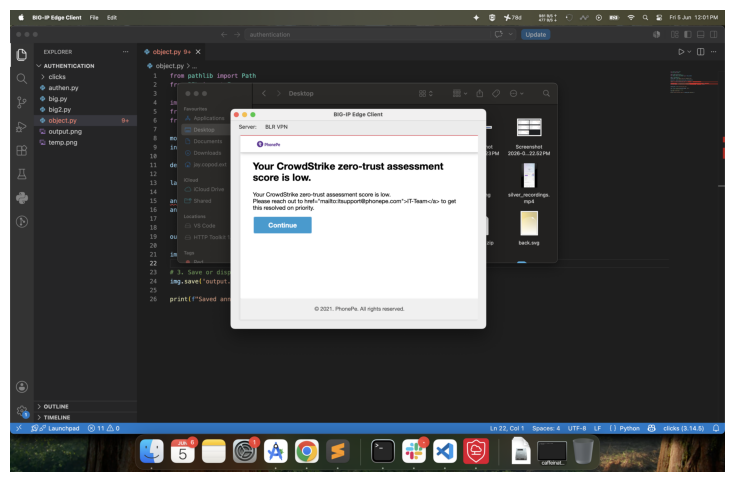

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Open the image file
img = Image.open('temp.png')

# Print image details
print(f"Format: {img.format}")
print(f"Size: {img.size}")
print(f"Mode: {img.mode}")

# Display the image
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
from pydantic import BaseModel, Field

SCREENSHOT_URL = "https://your-host/screenshot.png"  # or "data:image/png;base64,..."
SCREENSHOT_WIDTH, SCREENSHOT_HEIGHT = 1280, 720
ELEMENT = "the 'Sign in' button in the top-right corner"

class VisualLocalizerOutput(BaseModel):
    x: int = Field(ge=0, le=1000, description="X coordinate as integer in [0, 1000]")
    y: int = Field(ge=0, le=1000, description="Y coordinate as integer in [0, 1000]")

schema = VisualLocalizerOutput.model_json_schema()

prompt = (
    "Localize an element on the GUI image according to the provided target "
    "and output a click position.\n"
    f" * You must output a valid JSON following the format: {schema}\n"
    f" Your target is:\n{ELEMENT}"
)

response = llm.chat.completions.create(
    messages=[{
        "role": "user",
        "content": [
            {"type": "image_url", "image_url": {"url": SCREENSHOT_URL}},
            {"type": "text", "text": prompt},
        ],
    }],
    extra_body={
        "structured_outputs": {"json": schema},
        "chat_template_kwargs": {"enable_thinking": False},
    },
    temperature=0.0,
)

point = VisualLocalizerOutput.model_validate_json(response.choices[0].message.content)
abs_x = int(point.x / 1000 * SCREENSHOT_WIDTH)
abs_y = int(point.y / 1000 * SCREENSHOT_HEIGHT)
print(f"Click at ({abs_x}, {abs_y})")